# Time series analysis

In this notebook we analyze the ECG signals presents in the provided data.
Precisely, we pre-process every TS and approximate them (or we extract some features from them). 

Before starting, install `wfdb`: an open source library of tools for reading, writing, and processing signals and annotations

In [1]:
!pip install wfdb 

## Defining utilities

In this section, we define helper functions to navigate and load the ECG time series data. The dataset follows the PhysioNet WFDB format with:
- **Header files (.hea)**: contain metadata (sampling rate, leads, duration)
- **Data files (.dat)**: contain the actual ECG signal values

### Data Organization
The ECG records are organized in a hierarchical structure:

time-series-project2025/ <br>
└── subject_id_hadm_id/ # e.g., 10000980_42546971 <br>
├── hadm_id.hea # e.g., 42546971.hea <br>
└── hadm_id.dat # e.g., 42546971.dat <br>


Each folder name combines:
- **subject_id**: unique patient identifier (8 digits)
- **hadm_id**: hospital admission identifier (8 digits)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

### 1. Directory Navigation Functions
These functions help locate the ECG data directory automatically, regardless of where the notebook is executed.


In [ ]:
from pathlib import Path
import os

def find_ecg_root():
    """
    Find the ECG data directory dynamically.
    """
    
    possible_paths = [
        Path.cwd().parent.parent / "data" / "time-series-project2025",
        Path.cwd().parent.parent.parent / "data" / "time-series-project2025",
    ]
    
    for path in possible_paths:
        if path.exists():
            print(f"✓ Directory found: {path}")
            return path
    
    raise FileNotFoundError("Directory time-series-project2025 not found")

ecg_root_dir = find_ecg_root()

✓ Directory found: /home/gabriele/DAD/data/time-series-project2025


### 2. Record Discovery Functions
These functions scan the directory tree to find all available ECG records and parse their identifiers.


In [4]:
def find_ecg_records(ecg_root_dir=None):
    """Find all ECG records in the dataset directory."""
    if ecg_root_dir is None:
        ecg_root_dir = find_ecg_root()
    
    records = []
    for root, _, files in os.walk(ecg_root_dir):
        for f in files:
            if f.endswith(".hea"):
                record_name = f.replace(".hea", "")
                records.append(os.path.join(root, record_name))
    
    return records

In [5]:
def parse_ecg_filename(filename, root_path):
    """
    Parse ECG filename to extract subject_id and hadm_id.
    
    The naming convention is:
    - Folder: subject_id_hadm_id (e.g., 10000980_42546971)
    - File: hadm_id.hea (e.g., 42546971.hea)
    
    Parameters
    ----------
    filename : str
        ECG record filename (without .hea extension).
    root_path : str
        Full path to the record's directory.
    
    Returns
    -------
    tuple
        (subject_id, hadm_id) or (None, hadm_id) if parsing fails.
    """
    # Get parent directory name (should be subject_id_hadm_id)
    parent_dir = os.path.basename(root_path)
    
    # Check if parent directory contains underscore separator
    # Format: subject_id_hadm_id
    if '_' in parent_dir:
        parts = parent_dir.split('_')
        if len(parts) >= 2:
            subject_id = parts[0]
            hadm_id = parts[1]
            return subject_id, hadm_id
    
    # Alternative: check if filename itself contains underscore
    if '_' in filename:
        parts = filename.split('_')
        subject_id = parts[0]
        hadm_id = parts[1] if len(parts) > 1 else filename
        return subject_id, hadm_id
    
    # If no pattern matches, return None for subject_id
    return None, filename

### 3. Patient-Specific Functions
These functions filter ECG records by patient ID, enabling patient-level analysis as required by Task 3.


In [6]:
import pandas as pd


def find_patient_ecg_records(subject_id, ecg_root_dir=None):
    """
    Find all ECG records for a given subject_id.

    Parameters
    ----------
    subject_id : str or int
        The patient's subject_id to search for.
    ecg_root_dir : str or Path, optional
        Root directory containing ECG data. If None, will try to find it automatically.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: subject_id, hadm_id, record_id, record_path.
        Empty DataFrame if no records found.

    Examples
    --------
    >>> patient_ecgs = find_patient_ecg_records('10000980')
    >>> print(f"Found {len(patient_ecgs)} ECG records")
    """
    # Find ECG root directory if not provided
    if ecg_root_dir is None:
        try:
            ecg_root_dir = find_ecg_root()
        except FileNotFoundError as e:
            print(f"Error: {e}")
            return pd.DataFrame(
                columns=["subject_id", "hadm_id", "record_id", "record_path"]
            )

    # Convert subject_id to string for comparison
    subject_id = str(subject_id)
    patient_records = []

    # Walk through directory tree
    for root, dirs, files in os.walk(ecg_root_dir):
        for f in files:
            if f.endswith(".hea"):
                record_name = f.replace(".hea", "")

                # Parse filename to extract IDs
                file_subject_id, hadm_id = parse_ecg_filename(record_name, root)

                # Check if this record belongs to the requested patient
                if file_subject_id == subject_id:
                    record_path = os.path.join(root, record_name)

                    patient_records.append(
                        {
                            "subject_id": file_subject_id,
                            "hadm_id": hadm_id,
                            "record_id": record_name,
                            "record_path": record_path,
                        }
                    )

    return pd.DataFrame(patient_records)

In [7]:
def create_complete_ecg_index(ecg_root_dir=None):
    """
    Create a complete index of all ECG records in the database.
    
    Parameters
    ----------
    ecg_root_dir : str or Path, optional
        Root directory containing ECG data. If None, will try to find it automatically.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with all ECG records and their metadata.
    """
    # Find ECG root directory if not provided
    if ecg_root_dir is None:
        ecg_root_dir = find_ecg_root()
    
    all_records = []
    
    # Walk through directory tree
    for root, dirs, files in os.walk(ecg_root_dir):
        for f in files:
            if f.endswith('.hea'):
                record_name = f.replace('.hea', '')
                
                # Parse filename to extract IDs
                subject_id, hadm_id = parse_ecg_filename(record_name, root)
                record_path = os.path.join(root, record_name)
                
                all_records.append({
                    'subject_id': subject_id,
                    'hadm_id': hadm_id,
                    'record_id': record_name,
                    'record_path': record_path
                })
    
    return pd.DataFrame(all_records)


### 4. Data Loading Functions
This function loads the actual time series data from WFDB files and extracts a specific ECG lead.

**Available ECG Leads:**
- **Limb leads**: I, II, III, aVR, aVL, aVF
- **Precordial leads**: V1, V2, V3, V4, V5, V6

For this analysis, we focus on **Lead II** as it typically provides clear P-QRS-T complexes.


In [8]:
import wfdb

def load_patient_timeseries(record_path, lead='II'):
    """
    Load time series for a specific ECG record.
    
    Parameters
    ----------
    record_path : str
        Path to the ECG record (without extension).
    lead : str, default='II'
        ECG lead to extract (e.g., 'I', 'II', 'III', 'aVR', 'V1', etc.).
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns: timestamp, value.
    
    Raises
    ------
    ValueError
        If the specified lead is not found in the record.
    """
    import numpy as np
    
    # Read ECG record
    sig, fields = wfdb.rdsamp(record_path)
    fs = fields['fs']
    
    # Check if lead exists
    if lead not in fields['sig_name']:
        available_leads = ', '.join(fields['sig_name'])
        raise ValueError(
            f"Lead '{lead}' not found in record. "
            f"Available leads: {available_leads}"
        )
    
    # Extract lead index
    lead_idx = fields['sig_name'].index(lead)
    
    # Create time series
    n_samples = sig.shape[0]
    timestamps = np.arange(n_samples) / fs
    values = sig[:, lead_idx]
    
    return pd.DataFrame({
        'timestamp': timestamps,
        'value': values
    })

Example of usage of these functions:

In [9]:
subject_id = "10000980"

print(f"Searching for ECG records of patient {subject_id}...")
patient_ecgs = find_patient_ecg_records(subject_id=subject_id)

if len(patient_ecgs) > 0:
    print(f"\n✓ Found {len(patient_ecgs)} ECG record(s) for patient {subject_id}")
    print("\nRecord details:")
    print(patient_ecgs)

    # Load first record as example
    if len(patient_ecgs) > 0:
        print(f"\n--- Loading first record ---")
        first_record = patient_ecgs.iloc[0]
        ts = load_patient_timeseries(first_record["record_path"], lead="II")
        print(f"Time series shape: {ts.shape}")
        print(f"Duration: {ts['timestamp'].max():.2f} seconds")
        print("\nFirst few samples:")
        print(ts.head())
else:
    print(f"\n✗ No ECG records found for patient {subject_id}")

# Example 2: Create complete index
print("\n" + "=" * 60)
print("Creating complete ECG index...")
ecg_index = create_complete_ecg_index()
print(f"\nTotal records: {len(ecg_index)}")
print(f"Unique patients: {ecg_index['subject_id'].nunique()}")
print(f"Unique admissions: {ecg_index['hadm_id'].nunique()}")
print("\nFirst 10 records:")
print(ecg_index.head(10))

Searching for ECG records of patient 10000980...
✓ Directory found: /home/gabriele/DAD/data/time-series-project2025

✓ Found 1 ECG record(s) for patient 10000980

Record details:
  subject_id   hadm_id record_id  \
0   10000980  42546971  42546971   

                                         record_path  
0  /home/gabriele/DAD/data/time-series-project202...  

--- Loading first record ---
Time series shape: (5000, 2)
Duration: 10.00 seconds

First few samples:
   timestamp  value
0      0.000 -0.020
1      0.002 -0.005
2      0.004 -0.005
3      0.006 -0.010
4      0.008 -0.020

Creating complete ECG index...
✓ Directory found: /home/gabriele/DAD/data/time-series-project2025

Total records: 1786
Unique patients: 1786
Unique admissions: 1786

First 10 records:
  subject_id   hadm_id record_id  \
0   12654170  40749293  40749293   
1   12839165  42104329  42104329   
2   10332928  42050030  42050030   
3   11469226  43465495  43465495   
4   16941887  49122309  49122309   
5   19968075  

## TS Pre-processing

At this point, we can produce one time series for each patient's ECG record.

According to the project guidelines, we need to:
1. Create **univariate** time series (one lead per patient)
2. Apply normalization techniques to make signals comparable
3. Handle noise and artifacts
4. Prepare data for clustering and classification tasks

### Pre-processing Pipeline

We apply the following transformations seen during the lectures:

1. **Baseline Correction** (Offset translation)
   - Remove DC offset to center the signal around zero
   - Formula: `x'(t) = x(t) - mean(x)`

2. **Amplitude Normalization** (Amplitude scaling)
   - Standardize signal amplitude across patients
   - Methods: Min-Max scaling or Z-score normalization

3. **Detrending** (Linear Trend removal)
   - Remove long-term drift in the signal
   - Use linear or polynomial detrending

4. **Noise Filtering** (Noise removal)
   - Apply band-pass filtering to remove baseline wander and high-frequency noise
   - Typical ECG frequency range: 0.5-40 Hz
"""

Below we define the functions that apply these transformations:

In [10]:
import numpy as np
from scipy import signal
from scipy.signal import butter, filtfilt, detrend

In [11]:
def baseline_correction(ts_data):
    """
    Remove DC offset by centering the signal around zero.
    
    Parameters
    ----------
    ts_data : pd.DataFrame
        Time series with 'timestamp' and 'value' columns.
    
    Returns
    -------
    pd.DataFrame
        Corrected time series.
    """
    corrected = ts_data.copy()
    corrected['value'] = ts_data['value'] - ts_data['value'].mean()
    return corrected

In [12]:
def normalize_amplitude(ts_data, method='zscore'):
    """
    Normalize signal amplitude.
    
    Parameters
    ----------
    ts_data : pd.DataFrame
        Time series with 'timestamp' and 'value' columns.
    method : str, default='zscore'
        Normalization method: 'zscore' or 'minmax'.
    
    Returns
    -------
    pd.DataFrame
        Normalized time series.
    """
    normalized = ts_data.copy()
    
    if method == 'zscore':
        # Z-score normalization: (x - μ) / σ
        mean = ts_data['value'].mean()
        std = ts_data['value'].std()
        normalized['value'] = (ts_data['value'] - mean) / std
        
    elif method == 'minmax':
        # Min-Max scaling: (x - min) / (max - min)
        min_val = ts_data['value'].min()
        max_val = ts_data['value'].max()
        normalized['value'] = (ts_data['value'] - min_val) / (max_val - min_val)
    
    return normalized

In [13]:
def remove_linear_trend(ts_data):
    """
    Remove linear trend from the signal.
    
    Parameters
    ----------
    ts_data : pd.DataFrame
        Time series with 'timestamp' and 'value' columns.
    
    Returns
    -------
    pd.DataFrame
        Detrended time series.
    """
    detrended = ts_data.copy()
    detrended['value'] = detrend(ts_data['value'], type='linear')
    return detrended

In [14]:
def bandpass_filter(ts_data, lowcut=0.5, highcut=40, fs=500, order=4):
    """
    Apply bandpass filter to remove noise.
    
    Typical ECG signal frequencies are between 0.5 Hz (baseline wander)
    and 40 Hz (muscle noise).
    
    Parameters
    ----------
    ts_data : pd.DataFrame
        Time series with 'timestamp' and 'value' columns.
    lowcut : float, default=0.5
        Low cutoff frequency (Hz).
    highcut : float, default=40
        High cutoff frequency (Hz).
    fs : float, default=500
        Sampling frequency (Hz).
    order : int, default=4
        Filter order.
    
    Returns
    -------
    pd.DataFrame
        Filtered time series.
    """
    # Design Butterworth bandpass filter
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    
    # Apply filter (zero-phase filtering)
    filtered = ts_data.copy()
    filtered['value'] = filtfilt(b, a, ts_data['value'])
    
    return filtered


### Applying pre-processing

In [15]:
def preprocess_ecg(ts_data, fs=500, apply_baseline=True, apply_normalize=True, 
                   apply_detrend=True, apply_filter=True, norm_method='zscore'):
    """
    Complete preprocessing pipeline for ECG signals.
    
    Parameters
    ----------
    ts_data : pd.DataFrame
        Raw time series with 'timestamp' and 'value' columns.
    fs : float, default=500
        Sampling frequency (Hz).
    apply_baseline : bool, default=True
        Whether to apply baseline correction.
    apply_normalize : bool, default=True
        Whether to normalize amplitude.
    apply_detrend : bool, default=True
        Whether to remove linear trend.
    apply_filter : bool, default=True
        Whether to apply bandpass filter.
    norm_method : str, default='zscore'
        Normalization method ('zscore' or 'minmax').
    
    Returns
    -------
    pd.DataFrame
        Preprocessed time series.
    """
    processed = ts_data.copy()
    
    # 1. Baseline correction
    if apply_baseline:
        processed = baseline_correction(processed)
    
    # 2. Remove linear trend
    if apply_detrend:
        processed = remove_linear_trend(processed)
    
    # 3. Bandpass filtering
    if apply_filter:
        processed = bandpass_filter(processed, fs=fs)
    
    # 4. Amplitude normalization (applied last)
    if apply_normalize:
        processed = normalize_amplitude(processed, method=norm_method)
    
    return processed


In [16]:
# Code cell: Visualization Functions
def plot_preprocessing_comparison(raw_ts, processed_ts, title="ECG Preprocessing"):
    """
    Compare raw and preprocessed signals side by side.
    
    Parameters
    ----------
    raw_ts : pd.DataFrame
        Raw time series.
    processed_ts : pd.DataFrame
        Preprocessed time series.
    title : str
        Plot title.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Raw signal
    ax1.plot(raw_ts['timestamp'], raw_ts['value'], 'b-', linewidth=0.5)
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Amplitude (mV)')
    ax1.set_title(f'{title} - Raw Signal')
    ax1.grid(True, alpha=0.3)
    
    # Preprocessed signal
    ax2.plot(processed_ts['timestamp'], processed_ts['value'], 'r-', linewidth=0.5)
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Normalized Amplitude')
    ax2.set_title(f'{title} - Preprocessed Signal')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


Here an example of pre-processing of a patient's ECG 

✓ Directory found: /home/gabriele/DAD/data/time-series-project2025


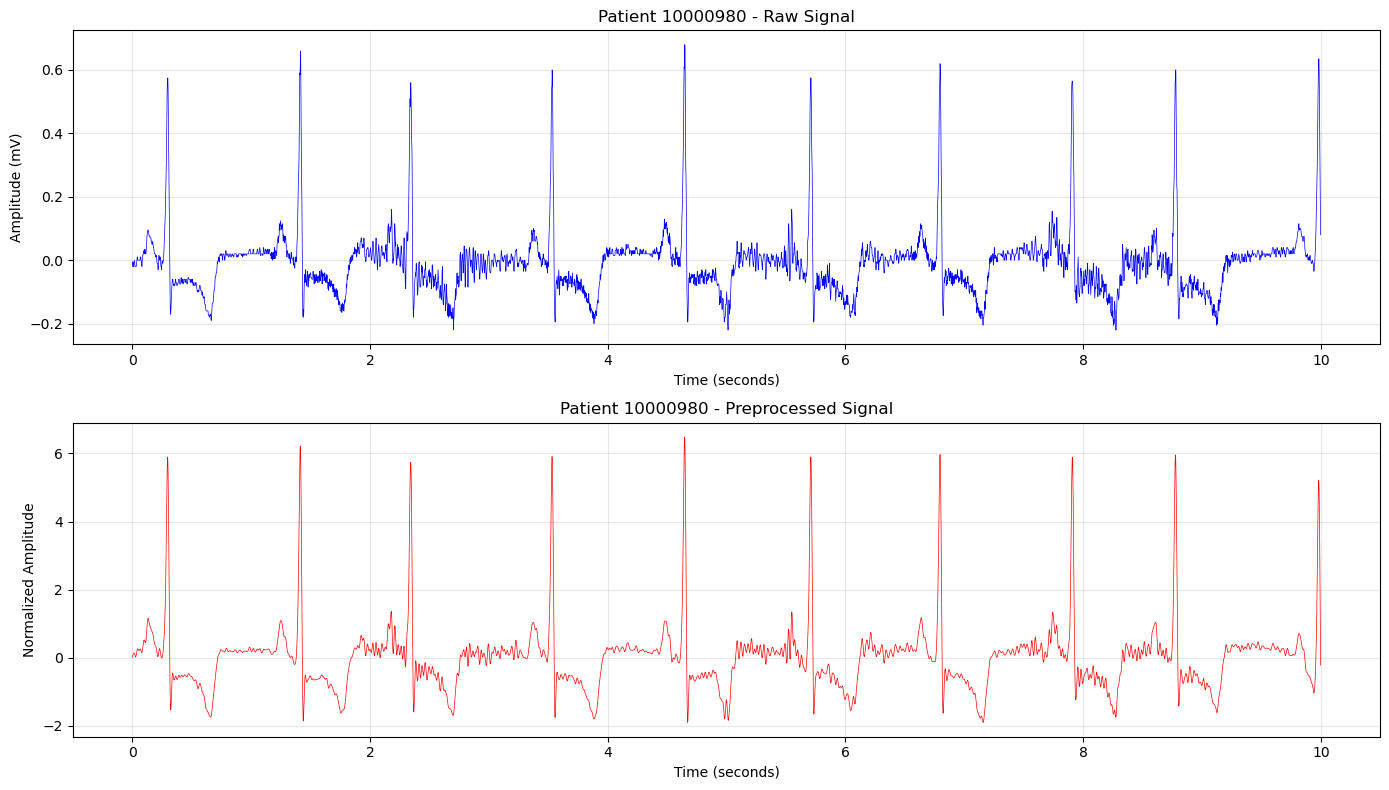

Raw Signal Statistics:
  Mean: -0.0084 mV
  Std:  0.1017 mV
  Min:  -0.2200 mV
  Max:  0.6800 mV

Processed Signal Statistics:
  Mean: -0.0000
  Std:  1.0000
  Min:  -1.8992
  Max:  6.4788


In [17]:
subject_id = "10000980"
patient_ecgs = find_patient_ecg_records(subject_id)

if len(patient_ecgs) > 0:
    first_record = patient_ecgs.iloc[0]
    
    # Load raw data
    raw_ts = load_patient_timeseries(first_record['record_path'], lead='II')
    
    # Apply preprocessing
    processed_ts = preprocess_ecg(
        raw_ts, 
        fs=500,
        apply_baseline=True,
        apply_normalize=True,
        apply_detrend=True,
        apply_filter=True,
        norm_method='zscore'
    )
    
    # Visualize comparison
    plot_preprocessing_comparison(raw_ts, processed_ts, 
                                   title=f"Patient {subject_id}")
    
    # Print statistics
    print("Raw Signal Statistics:")
    print(f"  Mean: {raw_ts['value'].mean():.4f} mV")
    print(f"  Std:  {raw_ts['value'].std():.4f} mV")
    print(f"  Min:  {raw_ts['value'].min():.4f} mV")
    print(f"  Max:  {raw_ts['value'].max():.4f} mV")
    
    print("\nProcessed Signal Statistics:")
    print(f"  Mean: {processed_ts['value'].mean():.4f}")
    print(f"  Std:  {processed_ts['value'].std():.4f}")
    print(f"  Min:  {processed_ts['value'].min():.4f}")
    print(f"  Max:  {processed_ts['value'].max():.4f}")


## Saving the normalized TS

In [18]:
def create_timeseries_dataframe(ecg_root_dir=None):
    """
    Create a single DataFrame with all preprocessed time series.
    
    Uses MultiIndex with (subject_id, hadm_id, timestamp) for efficient
    access and grouping operations.
    
    Parameters
    ----------
    ecg_root_dir : str or Path, optional
        Root directory containing ECG data.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with MultiIndex and 'value' column containing all time series.
    """
    # Get all ECG records
    if ecg_root_dir is None:
        ecg_root_dir = find_ecg_root()
    
    ecg_index = create_complete_ecg_index(ecg_root_dir)
    
    all_data = []
    
    print(f"Processing {len(ecg_index)} records...")
    
    for idx, record in ecg_index.iterrows():
        try:
            # Load and preprocess
            raw_ts = load_patient_timeseries(record['record_path'], lead='II')
            processed_ts = preprocess_ecg(raw_ts)
            
            # Add identifiers
            processed_ts['subject_id'] = record['subject_id']
            processed_ts['hadm_id'] = record['hadm_id']
            
            # Reorder columns
            processed_ts = processed_ts[['subject_id', 'hadm_id', 'timestamp', 'value']]
            
            all_data.append(processed_ts)
            
            if (idx + 1) % 10 == 0:
                print(f"  Processed {idx + 1}/{len(ecg_index)} records")
                
        except Exception as e:
            print(f"  Error with {record['record_id']}: {e}")
    
    # Concatenate all time series
    df_all = pd.concat(all_data, ignore_index=True)
    
    # Set MultiIndex for efficient queries
    df_all = df_all.set_index(['subject_id', 'hadm_id', 'timestamp'])
    
    print(f"\n✓ Created DataFrame with {len(df_all)} total samples")
    print(f"  Unique patients: {df_all.index.get_level_values('subject_id').nunique()}")
    print(f"  Memory usage: {df_all.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    return df_all


# Crea il DataFrame
df_timeseries = create_timeseries_dataframe()

# Visualizza struttura
print(df_timeseries.head(10))
print(f"\nShape: {df_timeseries.shape}")

✓ Directory found: /home/gabriele/DAD/data/time-series-project2025
Processing 1786 records...
  Processed 10/1786 records
  Processed 20/1786 records
  Processed 30/1786 records
  Processed 40/1786 records
  Processed 50/1786 records
  Processed 60/1786 records
  Processed 70/1786 records
  Processed 80/1786 records
  Processed 90/1786 records
  Processed 100/1786 records
  Processed 110/1786 records
  Processed 120/1786 records
  Processed 130/1786 records
  Processed 140/1786 records
  Processed 150/1786 records
  Processed 160/1786 records
  Processed 170/1786 records
  Processed 180/1786 records
  Processed 190/1786 records
  Processed 200/1786 records
  Processed 210/1786 records
  Processed 220/1786 records
  Processed 230/1786 records
  Processed 240/1786 records
  Processed 250/1786 records
  Processed 260/1786 records
  Processed 270/1786 records
  Processed 280/1786 records
  Processed 290/1786 records
  Processed 300/1786 records
  Processed 310/1786 records
  Processed 320/

In [19]:
df_timeseries.to_pickle('processed_timeseries.pkl')
print("✓ DataFrame saved to 'processed_timeseries.pkl'")

# Reloading
# df_loaded = pd.read_pickle('processed_timeseries.pkl')
# print(f"✓ Loaded DataFrame with shape: {df_loaded.shape}")


✓ DataFrame saved to 'processed_timeseries.pkl'
